Requirements to run:

torch, matplotlib, opencv-python, tqdm, numpy

train_sims.npy, val_sims.npy, test_sims.npy (You may need to change the paths)

the unet file, or replace the import with code from previous notebooks

Data in 200x200 format with conductivity, pressure, and porosity. (Again, you may need to change path)

At the bottom in the evaluation section, there are some pre-named models. You should replace these with the names of your saved models.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import numpy as np
from unet import *
from datasets import *
import os, re
from skimage.metrics import structural_similarity

RESULTS_DIR = "./results_eval"
os.makedirs(RESULTS_DIR, exist_ok=True)
EVAL_DIR = "./results_eval"
PLOTS_DIR = "./results_plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# Prevents crashes when showing graphs
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [5]:
# Required functions and constants
test_sims = np.load("../test_sims.npy")
train_sims = np.load("../train_sims.npy")
val_sims = np.load("../val_sims.npy")
test_sims = test_sims[test_sims < 250]

DEFAULT_VALS = {"sims": test_sims, "pps": 3, "radius": 5,
                 "steps": (0,200), "types": [0], "channels": "all"}

# Folders
# Folders
BINARY_FOLDER = "../Data200x200_withinfo"
UNIFORM_FOLDER = "../Uniform200x200withInfo"

# Get porosity phi
def get_phi(sim,step,folder):
    return cv2.imread(f"{folder}/Image-{sim}-{step}_phi.jpg", cv2.IMREAD_GRAYSCALE)

# Get pressure
def get_pres(sim,step,folder):
    return cv2.imread(f"{folder}/Image-{sim}-{step}_P.jpg", cv2.IMREAD_GRAYSCALE)

# Get conductivity K
def get_k(sim,step,folder):
    return cv2.imread(f"{folder}/Image-{sim}-{step}_K.jpg", cv2.IMREAD_GRAYSCALE)

# Get all 3 as a 3-channel matrix
def get_all(sim,step,folder):
    return np.array((get_k(sim,step,folder), get_pres(sim,step,folder), get_phi(sim,step,folder)), dtype=np.float32)

# Darcy loss function
def darcy_loss(model, inp):

    # Takes in the k,pres,phi and outputs the prediction across the image.
    inp = inp.requires_grad_(True)
    out = model(inp)
    # out is in order K,P,phi, (conductivity, pressure, porosity)

    # Impose high pressure along the entire upper line by setting the pressure channelt to 200.
    out[:, 1:2, 0, :] = 200

    # If we assume the output is in order k,pres,phi
    # pres_grad is the gradient of the pressure along the y and x directions as a tuple
    pres_grad = torch.gradient(out[:, 1:2], dim=(-2,-1))

    # get velocity by multiplying the gradient by the conductivity
    y_grad = pres_grad[0] * out[:, 0:1]
    x_grad = pres_grad[1] * out[:, 0:1]

    # compute the divergence by the second derivative of the gradients and adding them together
    yy_grad = torch.gradient(y_grad, spacing=(1,),dim=(-2,))[0]
    xx_grad = torch.gradient(x_grad, spacing=(1,),dim=(-1,))[0]
    final = yy_grad + xx_grad

    # total divergence should be 0
    loss = (final**2).mean()

    return loss, out

In [6]:
def modified_error(input, target):

    if input.shape != target.shape:
        raise ValueError(f"Shape mismatch: {input.shape} vs {target.shape}")

    # flatten all non-batch dims
    N = input.size(0)
    err = (input - target).pow(2).view(N, -1)       # (N, P)
    mse = err.mean(dim=1)                           # (N,)

    energy = target.pow(2).view(N, -1).mean(dim=1)  # (N,)
    nmse = mse / (energy + 0.00000001)

    return (nmse.mean(), mse.mean(), energy.mean())

In [7]:
def loss_matrix_2(dataset, model):
    with torch.inference_mode():
        K = len(dataset.types)
        n_sims = test_sims.shape[0]
        T = 200

        # Main metric: Normalized MSE
        darcy_losses = torch.zeros((K, n_sims, T), dtype=torch.float32)
        nmse_total   = torch.zeros((K, n_sims, T), dtype=torch.float32)
        nmse_k       = torch.zeros((K, n_sims, T), dtype=torch.float32)
        nmse_p       = torch.zeros((K, n_sims, T), dtype=torch.float32)
        nmse_phi     = torch.zeros((K, n_sims, T), dtype=torch.float32)

        # MSE + energy
        mse_total    = torch.zeros((K, n_sims, T), dtype=torch.float32)
        mse_k        = torch.zeros((K, n_sims, T), dtype=torch.float32)
        mse_p        = torch.zeros((K, n_sims, T), dtype=torch.float32)
        mse_phi      = torch.zeros((K, n_sims, T), dtype=torch.float32)

        e_total      = torch.zeros((K, n_sims, T), dtype=torch.float32)
        e_k          = torch.zeros((K, n_sims, T), dtype=torch.float32)
        e_p          = torch.zeros((K, n_sims, T), dtype=torch.float32)
        e_phi        = torch.zeros((K, n_sims, T), dtype=torch.float32)

        for t in tqdm(range(K)):
            for sim in tqdm(range(n_sims)):
                for step in range(T):
                    feat, label = dataset.__getitem__(t * n_sims * T + sim * T + step)
                    feat  = feat.to(device).unsqueeze(0)
                    label = label.to(device).unsqueeze(0)

                    p_loss, out = darcy_loss(model, feat)

                    # total per channel
                    nmse_t, mse_t, en_t     = modified_error(out, label)
                    nmseK, mseK, enK        = modified_error(out[:, 0], label[:, 0])
                    nmseP, mseP, enP        = modified_error(out[:, 1], label[:, 1])
                    nmsePhi, msePhi, enPhi  = modified_error(out[:, 2], label[:, 2])

                    # store
                    darcy_losses[t, sim, step] = float(p_loss.detach().cpu())

                    nmse_total[t, sim, step]   = float(nmse_t.detach().cpu())
                    nmse_k[t, sim, step]       = float(nmseK.detach().cpu())
                    nmse_p[t, sim, step]       = float(nmseP.detach().cpu())
                    nmse_phi[t, sim, step]     = float(nmsePhi.detach().cpu())

                    mse_total[t, sim, step]    = float(mse_t.detach().cpu())
                    mse_k[t, sim, step]        = float(mseK.detach().cpu())
                    mse_p[t, sim, step]        = float(mseP.detach().cpu())
                    mse_phi[t, sim, step]      = float(msePhi.detach().cpu())

                    e_total[t, sim, step]      = float(en_t.detach().cpu())
                    e_k[t, sim, step]          = float(enK.detach().cpu())
                    e_p[t, sim, step]          = float(enP.detach().cpu())
                    e_phi[t, sim, step]        = float(enPhi.detach().cpu())

        return (
            darcy_losses,
            nmse_total, nmse_k, nmse_p, nmse_phi,
            mse_total,  mse_k,  mse_p,  mse_phi,
            e_total,    e_k,    e_p,    e_phi,
        )

In [8]:
def loss_matrix_ssim(dataset, model):

    with torch.inference_mode():
        K = len(dataset.types)

        ssim_losses = torch.zeros((2, test_sims.shape[0], 200), dtype=torch.float16)

        for t in tqdm(range(K)):
            for sim in tqdm(range(test_sims.shape[0])):
                for step in range(200):

                    feat, label = dataset.__getitem__(t * test_sims.shape[0] * 200 + sim * 200 + step)
                    feat, label = feat.to(device).unsqueeze(0), label.to(device).unsqueeze(0)
                    p_loss, out = darcy_loss(model, feat)
                    out = out[0].permute(1,2,0).detach().cpu().numpy().astype(np.int8)
                    label = label[0].permute(1,2,0).detach().cpu().numpy().astype(np.int8)
                    ssim = structural_similarity(out, label, channel_axis=-1)
                    ssim_losses[t, sim, step] = ssim

        return ssim_losses

In [9]:
# Helpers
#=========
def model_name_from_path(path: str) -> str:
    # "file.pt" -> "file"
    return os.path.splitext(os.path.basename(path))[0]

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def get_params(model_dict):
    path = model_dict["path"]
    sims = model_dict["sims"] if "sims" in model_dict else DEFAULT_VALS["sims"]
    pps = model_dict["pps"] if "pps" in model_dict else DEFAULT_VALS["pps"]
    radius = model_dict["radius"] if "radius" in model_dict else DEFAULT_VALS["radius"]
    steps = model_dict["steps"] if "steps" in model_dict else DEFAULT_VALS["steps"]
    types = model_dict["types"] if "types" in model_dict else DEFAULT_VALS["types"]
    channels = model_dict["channels"] if "channels" in model_dict else DEFAULT_VALS["channels"]
    return path, sims, pps, radius, steps, types, channels

def load_eval(name, eval_dir):
    """Loads eval_{name}.npz, returns dict of arrays"""
    path = os.path.join(eval_dir, f"eval_{name}.npz")
    data = np.load(path)
    return {k: data[k] for k in data.files}

def _run_name(model_tags):
    if len(model_tags) == 1:
        return model_tags[0]
    head = "vs_".join(model_tags[:3])
    return head if len(model_tags) <= 3 else f"{head}_more"

In [10]:
def evaluate_and_save_npz(model_path, dataset, device):
    name = model_name_from_path(model_path)
    out_path = os.path.join(RESULTS_DIR, f"eval_{name}.npz")

    print(f"\n=== Evaluating: {name} ===")
    model = torch.load(model_path, weights_only=False, map_location=device)
    model.eval()

    (
        d,
        nmse_t, nmse_k, nmse_p, nmse_phi,
        mse_t,  mse_k,  mse_p,  mse_phi,
        e_t,    e_k,    e_p,    e_phi,
    ) = loss_matrix_2(dataset, model)

    np.savez(
        out_path,
        darcy=to_numpy(d),

        nmse=to_numpy(nmse_t),
        nmse_k=to_numpy(nmse_k),
        nmse_p=to_numpy(nmse_p),
        nmse_phi=to_numpy(nmse_phi),

        mse=to_numpy(mse_t),
        mse_k=to_numpy(mse_k),
        mse_p=to_numpy(mse_p),
        mse_phi=to_numpy(mse_phi),

        e=to_numpy(e_t),
        e_k=to_numpy(e_k),
        e_p=to_numpy(e_p),
        e_phi=to_numpy(e_phi),
    )

    del model
    torch.cuda.empty_cache()
    print(f"Saved: {out_path}")
    return out_path

In [11]:

def summarize_over_sims(arr, kind=0, percentiles=(10, 50, 90)):
    """
    Computes per timestep percentiles across simulations
    Input shape: (K, n_sims, T)
    Output: dict {percentile: array of shape (T,)}
    """
    if arr.ndim != 3:
        raise ValueError(f"Expected (K,n_sims,T) array, got shape {arr.shape}")
    if kind >= arr.shape[0]:
        raise ValueError(f"kind={kind} not available; arr has {arr.shape[0]} kinds")

    vals = arr[kind, :, :]
    p = np.percentile(vals.astype(np.float64), percentiles, axis=0)  # (len(pct), T)
    return {pct: series for pct, series in zip(percentiles, p)}

In [32]:
# Metrics
# --------------------------
METRICS = {
    "darcy":    ("Darcy residual", "Darcy residual"),

    # normalized
    "nmse":     ("Total error",     "Normalized MSE"),
    "nmse_k":   ("Conductivity K",  "Normalized MSE"),
    "nmse_p":   ("Pressure P",      "Normalized MSE"),
    "nmse_phi": ("Porosity",      "Normalized MSE"),

    # raw
    "mse":      ("Total error",     "Raw MSE"),
    "mse_k":    ("Conductivity K",  "Raw MSE"),
    "mse_p":    ("Pressure P",      "Raw MSE"),
    "mse_phi":  ("Porosity",      "Raw MSE"),
}

def plot_metric_timeseries(
    model_tags,
    metric_key,
    kind=0,                         # 0 for binary, 1 for uniform
    percentiles=(10, 50, 90),
    start_step=0,                   # starts graph off 0 to avoid inital extreme values.
    cap_percent=100,                # cap if extreme points skew graph
    # points options
    show_points=False,              # turn scatter points on
    transparency=0.05,              # point transparency
    point_stride=15,                # scatter points every 15 steps
    point_size=10,
    # scaling options
    log_y=False,                    # log scale y for darcy
    log_eps=1e-12,
    # folders
    eval_dir="results_eval",
    out_dir="results_plots",
):
    """
    Plot metric vs step for one or more models.
    Shows median (P50) across sims, a P10–P90 band, and optional scatter at every point_stride steps.
    """
    if metric_key not in METRICS:
        raise KeyError(f"Unknown metric_key={metric_key}. Options are: {list(METRICS.keys())}")

    kind_name = "Binary" if kind == 0 else "Uniform"
    title_name, ylabel = METRICS[metric_key]

    run_name = _run_name(model_tags)
    folder = os.path.join(out_dir, run_name)
    os.makedirs(folder, exist_ok=True)

    # log y scale for darcy
    if log_y is True:
        log_y = (metric_key == "darcy")

    plt.figure(figsize=(10, 5))
    all_plotted_vals = []

    for tag in model_tags:
        data = load_eval(tag, eval_dir=eval_dir)
        if metric_key not in data:
            raise KeyError(f"Metric '{metric_key}' not in eval file for tag='{tag}'. Found keys are: {list(data.keys())}")

        arr = data[metric_key]  # (K, n_sims, T)

        summ = summarize_over_sims(arr, kind=kind, percentiles=percentiles)
        p10, p50, p90 = summ[percentiles[0]][start_step:], summ[percentiles[1]][start_step:], summ[percentiles[2]][start_step:]
        all_plotted_vals.append(p10)
        all_plotted_vals.append(p50)
        all_plotted_vals.append(p90)

        T = p50.shape[0]
        x = np.arange(start_step, start_step + T)   # real step axis

        # For log plots, clip at eps so fill/lines don't break
        if log_y:
            p10 = np.maximum(p10, log_eps)
            p50 = np.maximum(p50, log_eps)
            p90 = np.maximum(p90, log_eps)

        line = plt.plot(x, p50, linewidth=2, label=tag)[0]
        c = line.get_color()
        plt.fill_between(x, p10, p90, alpha=0.15, color=c)

        if show_points:
            vals = arr[kind, :, :].astype(np.float64)  # (n_sims, T)
            steps = np.arange(start_step, start_step + T, point_stride)

            for s in steps:
                vv = vals[:, s]
                if log_y:
                    vv = np.maximum(vv, log_eps)
                xx = np.full_like(vv, s, dtype=np.float64)
                plt.scatter(xx, vv, s=point_size, alpha=transparency, color=c)

    plt.title(f"{title_name} vs Step — {kind_name}")
    plt.xlabel("Step")
    plt.ylabel(ylabel)
    if log_y:
        plt.yscale("log")

    plt.legend()
    plt.tight_layout()

    save_path = os.path.join(folder, f"{metric_key}_{kind_name.lower()}_timeseries.png")
    if cap_percent is not None:
        flat = np.concatenate([v.ravel() for v in all_plotted_vals])
        flat = flat[np.isfinite(flat)]

        if flat.size > 0:
            ymax = np.percentile(flat, cap_percent)
            plt.ylim(top=ymax)
    plt.ylim(bottom=0)
    plt.savefig(save_path, dpi=200)
    plt.show()
    return save_path


In [26]:
def plot_combined_summary_bar(
    model_tags,
    kind=0,
    percentiles=(10, 50, 90),
    eval_dir="results_eval",
    out_dir="results_plots",
):
    """
    Creates a bar chart comparing models across metrics.

    For each model and each metric:
      1) compute the per step median(p50) across simulations,
      2) collapse across time by taking the median over steps,
      3) plot those as grouped bars.
    """
    kind_name = "Binary" if kind == 0 else "Uniform"
    run_name = _run_name(model_tags)
    folder = os.path.join(out_dir, run_name)
    os.makedirs(folder, exist_ok=True)

    metric_keys   = ["nmse", "nmse_k", "nmse_p", "nmse_phi"]
    metric_labels = ["Total", "K",      "P",      "Phi"]

    summary = {tag: [] for tag in model_tags}

    for tag in model_tags:
        data = load_eval(tag, eval_dir=eval_dir)

        for mk in metric_keys:
            arr = data[mk]  # (K,n_sims,T)
            summ = summarize_over_sims(arr, kind=kind, percentiles=percentiles)
            p50 = summ[50].astype(np.float64)

            scalar = float(np.median(p50))  # median over time
            summary[tag].append(scalar)

    x = np.arange(len(metric_keys))
    width = 0.8 / max(1, len(model_tags))

    plt.figure(figsize=(10, 5))
    for i, tag in enumerate(model_tags):
        plt.bar(x + i*width, summary[tag], width=width, label=tag)

    plt.xticks(x + width*(len(model_tags)-1)/2, metric_labels)
    plt.title(f"Metric summary — {kind_name}")
    plt.ylabel("Median of P50")
    plt.legend()
    plt.tight_layout()

    save_path = os.path.join(folder, f"combined_summary_{kind_name.lower()}.png")
    plt.savefig(save_path, dpi=200)
    plt.show()

    return save_path

Evaluation & Plotting Summary

This code evaluates trained models on the test dataset and saves all error metrics over time (Darcy loss, normalized MSE, and raw MSE for each field) to ```results_eval/eval_{model}.npz```
Each model is evaluated once, then results are stored in the .npz file.

Plotting is done after evaluation by loading results.

	•	plotting metrics vs. time,
	•	comparing multiple models on the same plots,
	•	summary bar charts

without rerunning model evaluations.

The evaluation step produces the data; the plotting step only visualizes.

In [14]:
# Each entry defines one model to evaluate.
# "path" is required all other fields fall back to `DEFAULT_VALS`.
# Optional:
#   sims     : train_sims | val_sims | test_sims
#   pps      : int
#   radius   : int 
#   steps    : (start, end)
#   types    : [0] | [1] | [0,1] (binary / uniform)
#   channels : "all" | "K" | "P" | "phi"
models_to_eval = [
    # {"path": "./full_d6_n16_With_D.pt"},
    {}
]

In [15]:
# Each entry is a plotting group.
# Model names must match the eval filenames:
#   eval_<model_name>.npz
#   ["full_d6_n16_With_D"]                     # single model
#   ["full_d6_n16_With_D", "full_d6_n16_NO_D"] # compare two models
models_to_plot = [
    ["full_d6_n16_With_D", "full_d6_n16_NO_D"]
]

In [ ]:
#paths for all evaluated models
eval_npz_paths = []

for md in models_to_eval:
    path, sims, pps, radius, steps, types, channels = get_params(md)
    dataset = FixedDenseDatasetFull(sims,points_per_side=pps,radius=radius,steps=steps,types=types,channels=channels)

    eval_npz_paths.append(evaluate_and_save_npz(path, dataset, device))

/var/folders/qm/z45q_dj168lbjph6mvbqnhg40000gn/T/ipykernel_40893/3190076789.py:113: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(bottom=0)


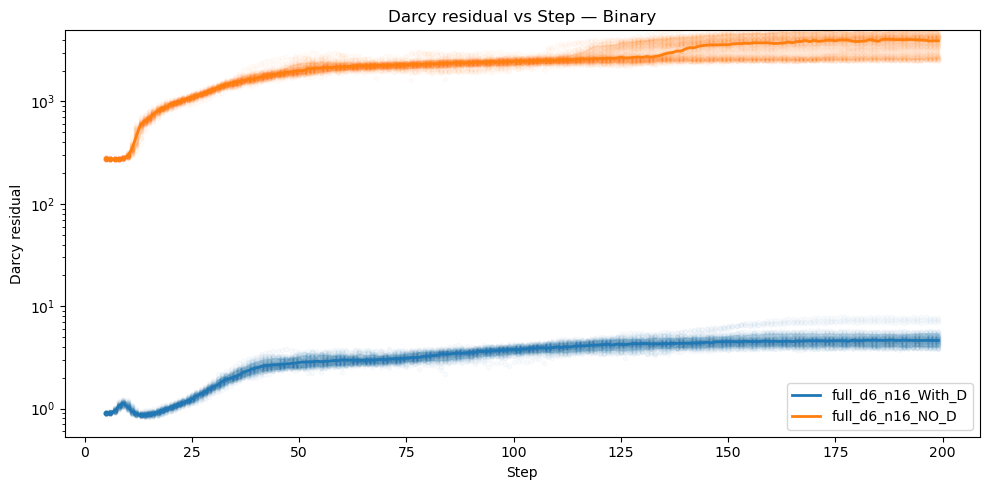

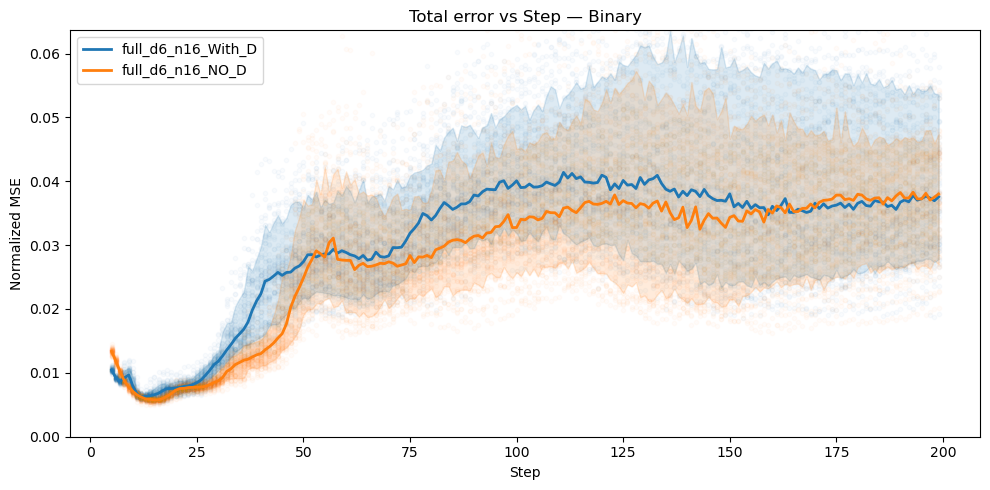

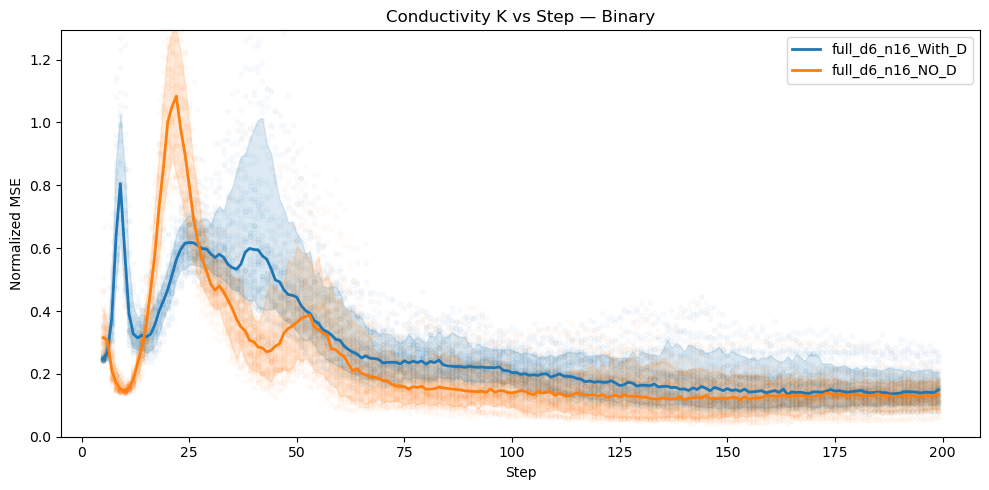

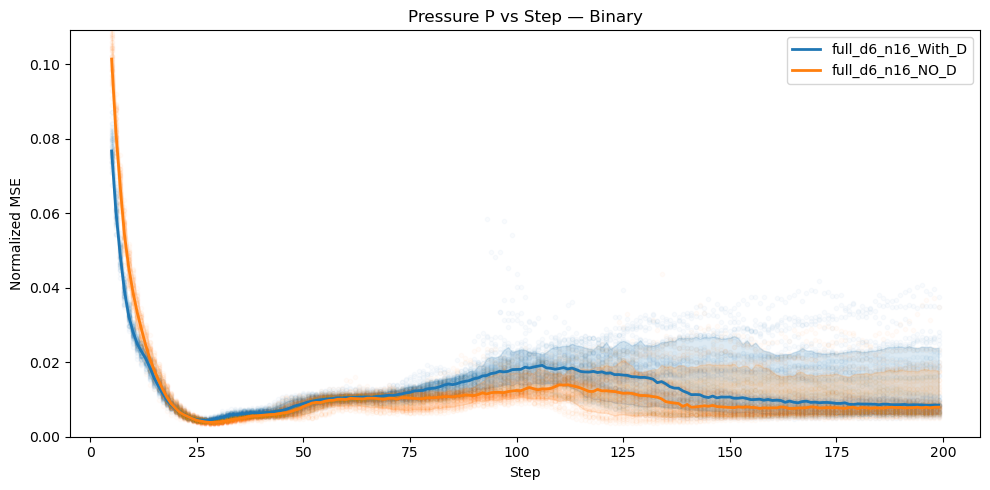

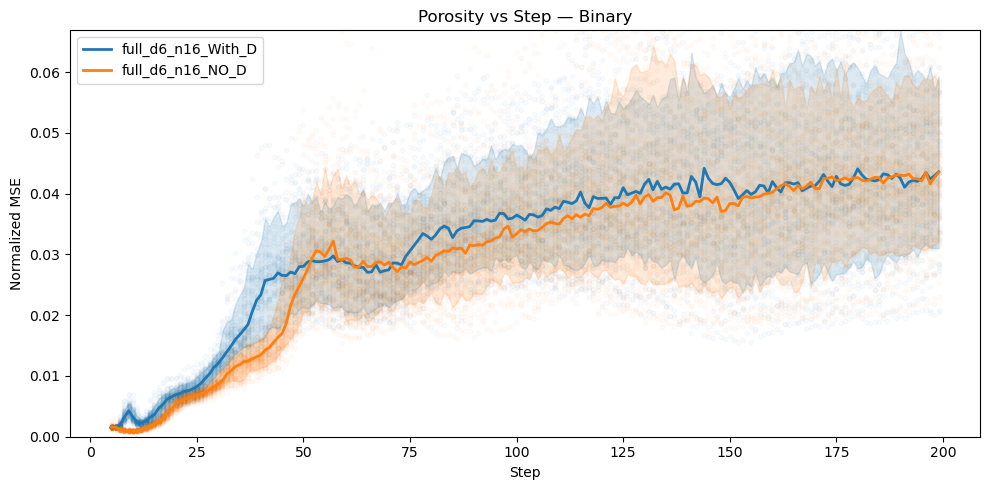

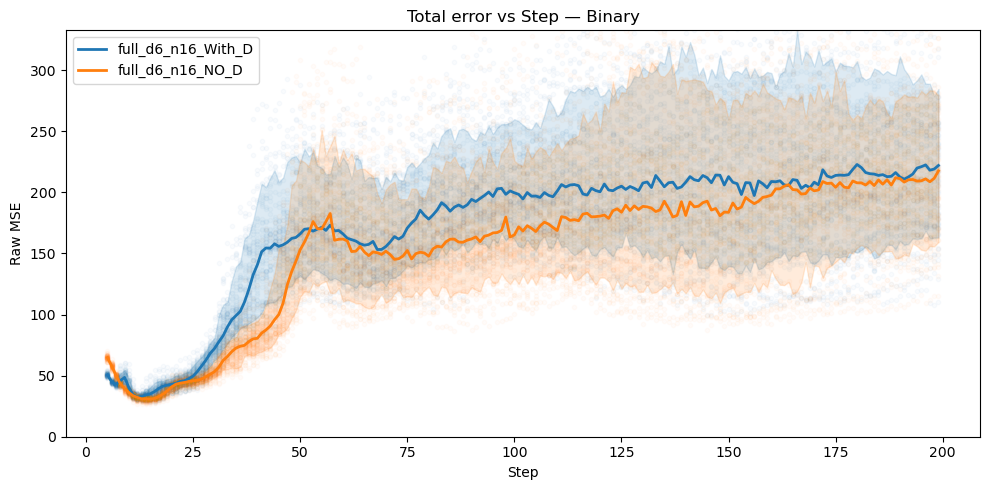

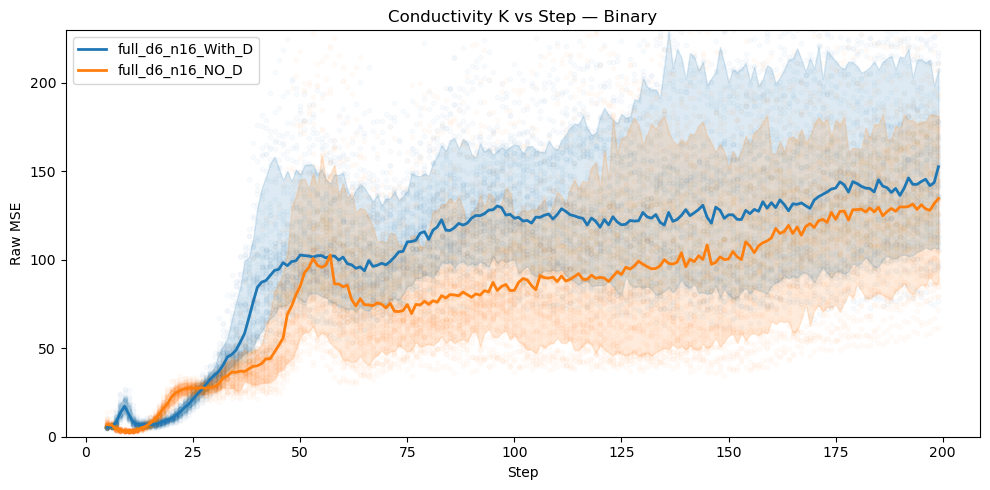

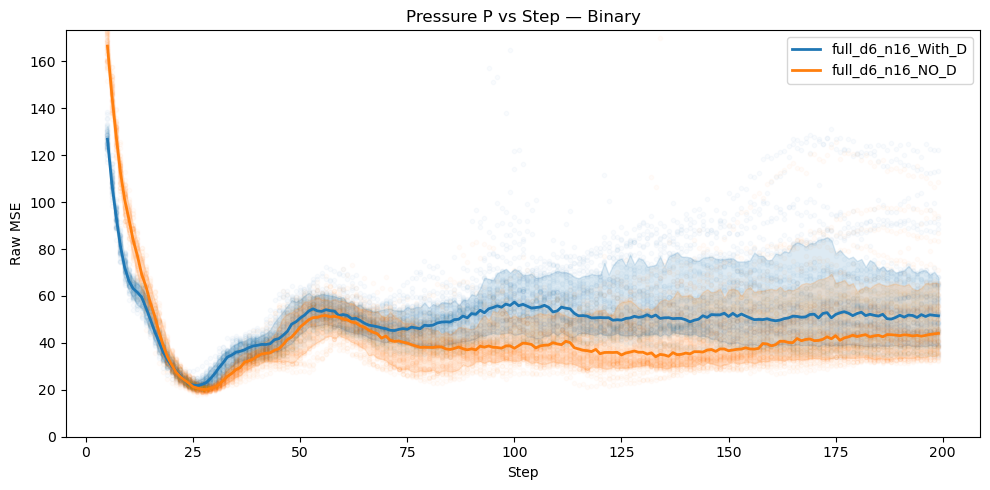

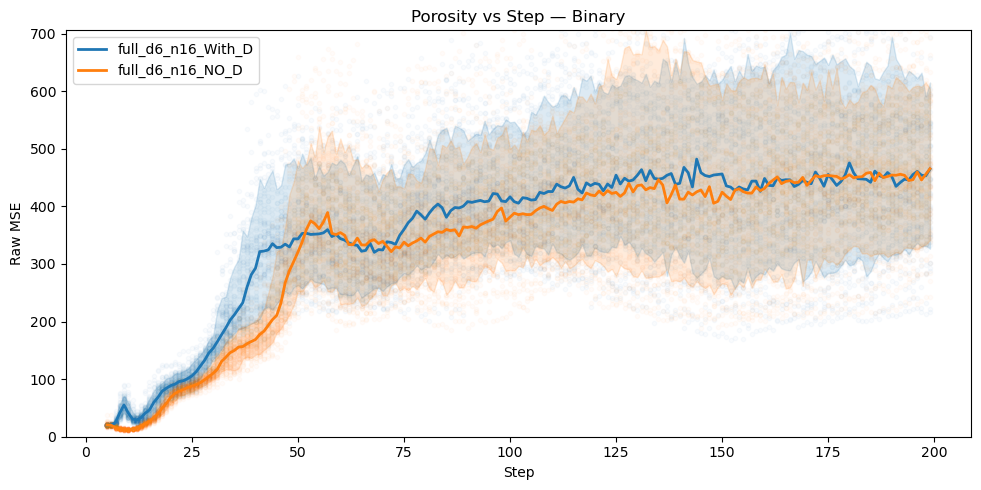

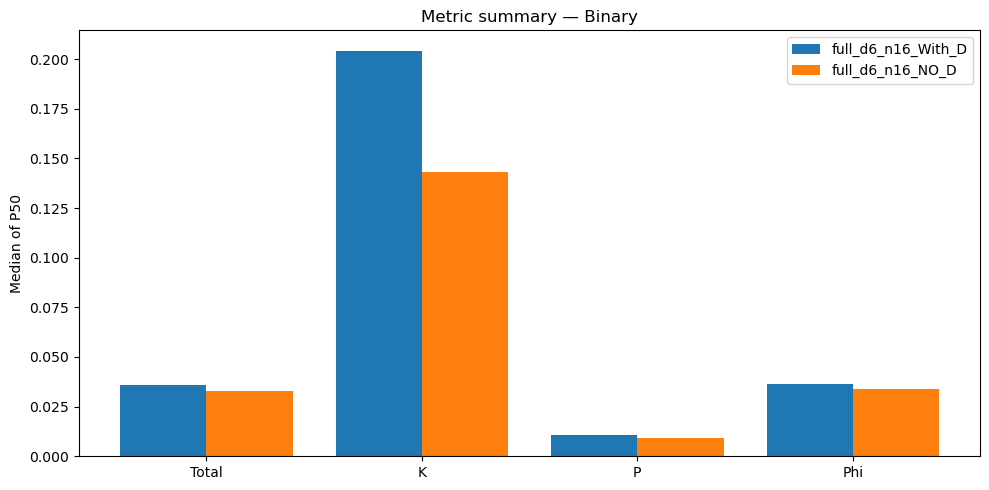

In [38]:
model_names = ["full_d6_n16_With_D", "full_d6_n16_NO_D"]

# One plot per metric (normalized + darcy)
for model_names in models_to_plot:
    for mk in METRICS.keys():
        plot_metric_timeseries(
            model_names,
            mk,
            kind=0,
            start_step=5,
            show_points=True,
            point_stride=1,
            transparency=0.025,
            log_y=True,
        )

    # Combined summary (nmse)
    plot_combined_summary_bar(model_names, kind=0)

/var/folders/qm/z45q_dj168lbjph6mvbqnhg40000gn/T/ipykernel_40893/3190076789.py:113: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(bottom=0)


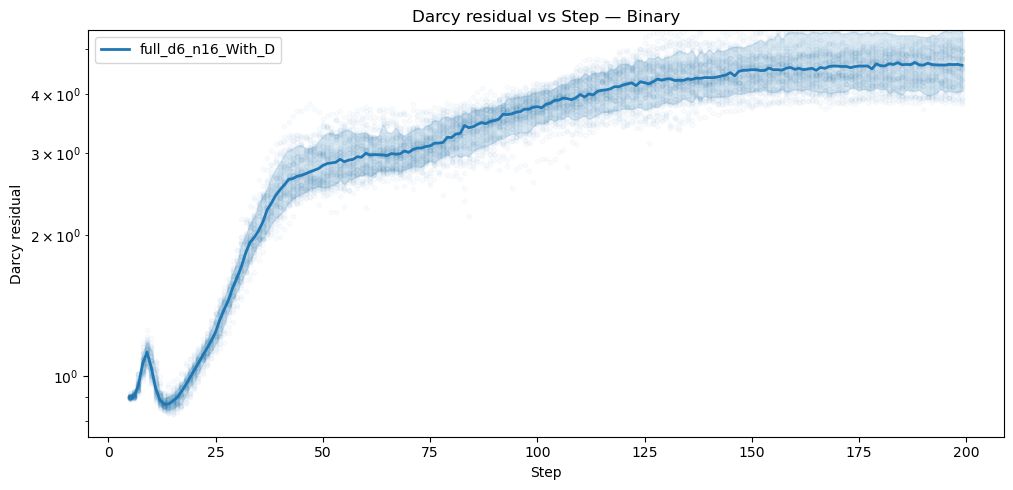

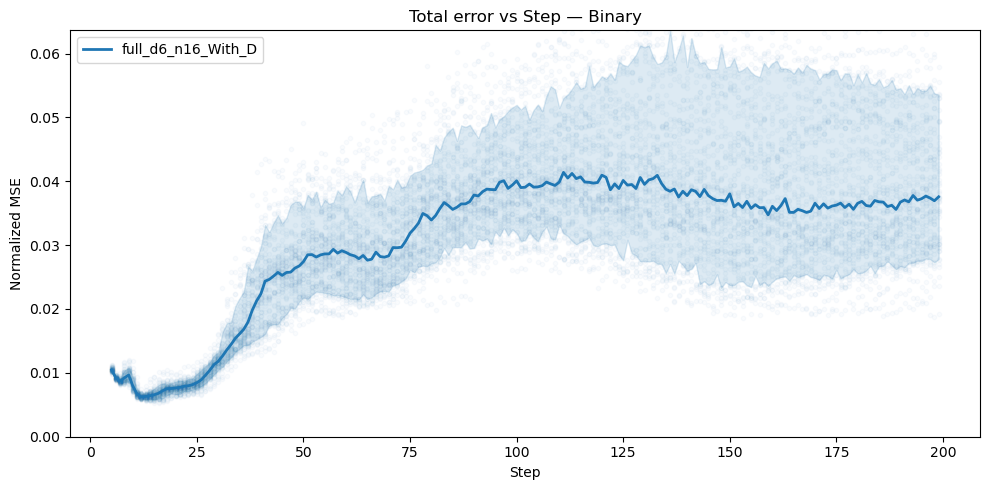

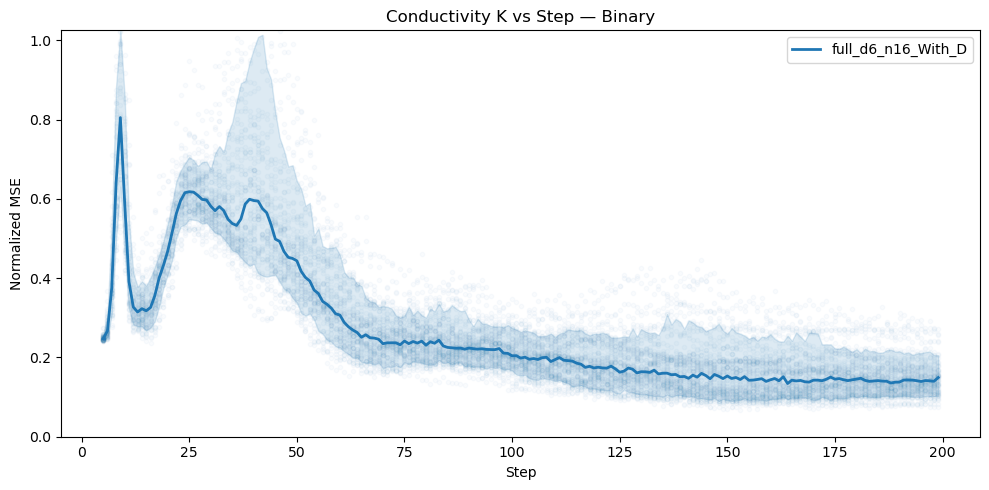

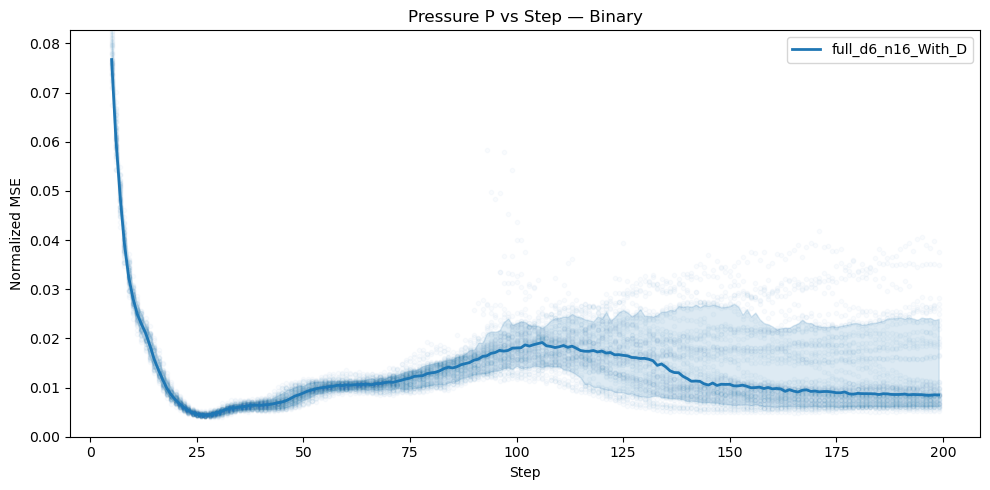

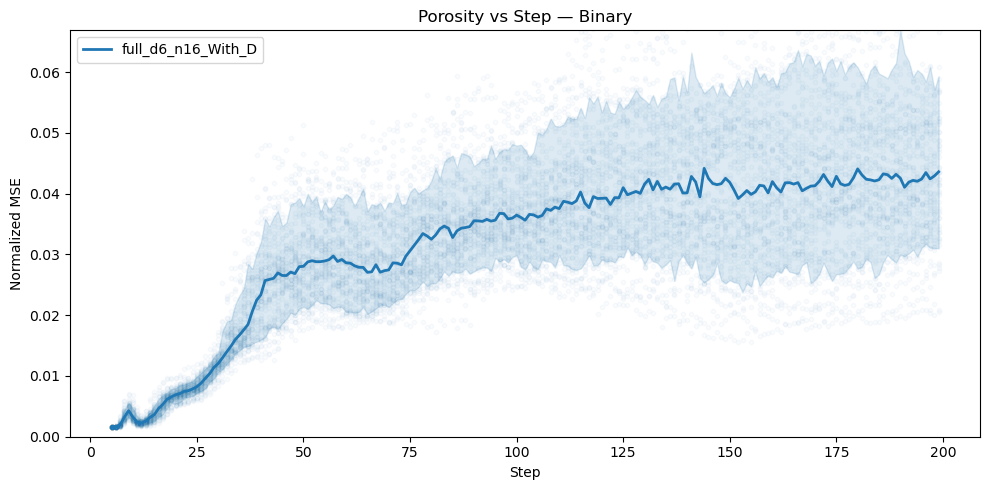

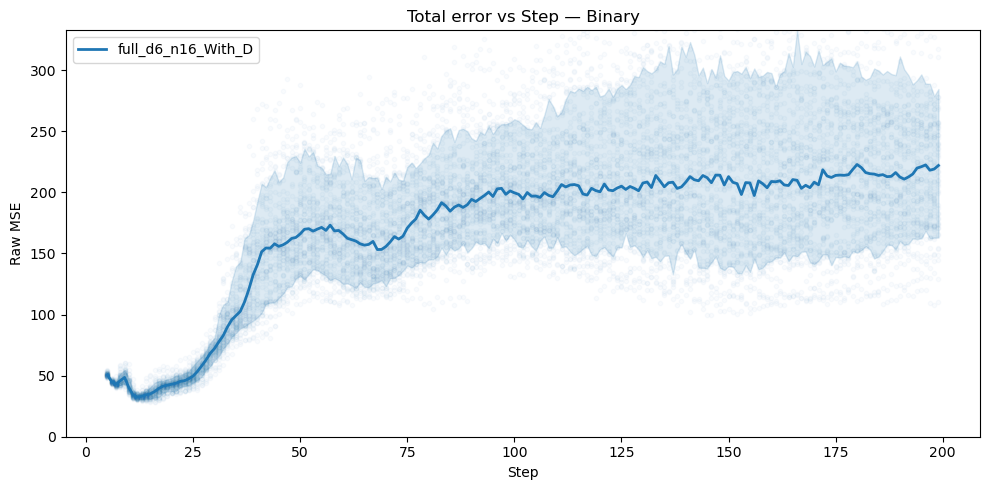

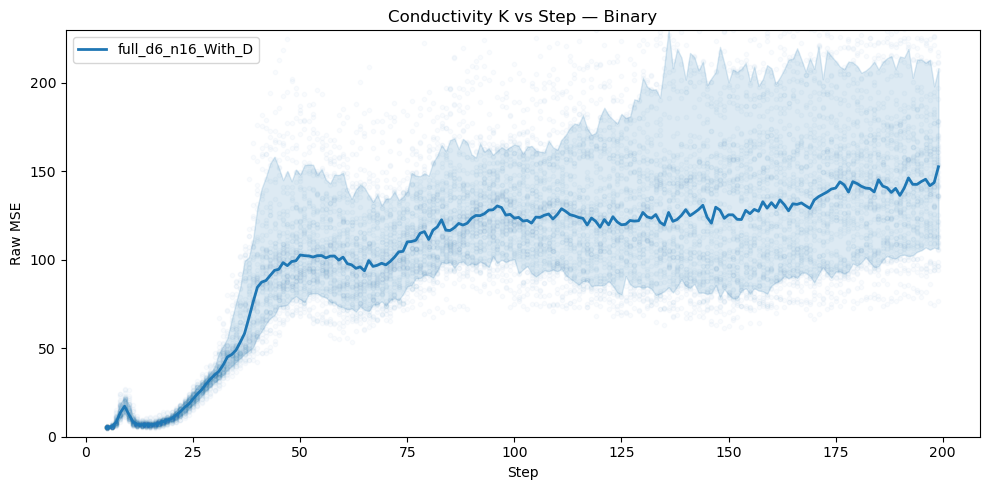

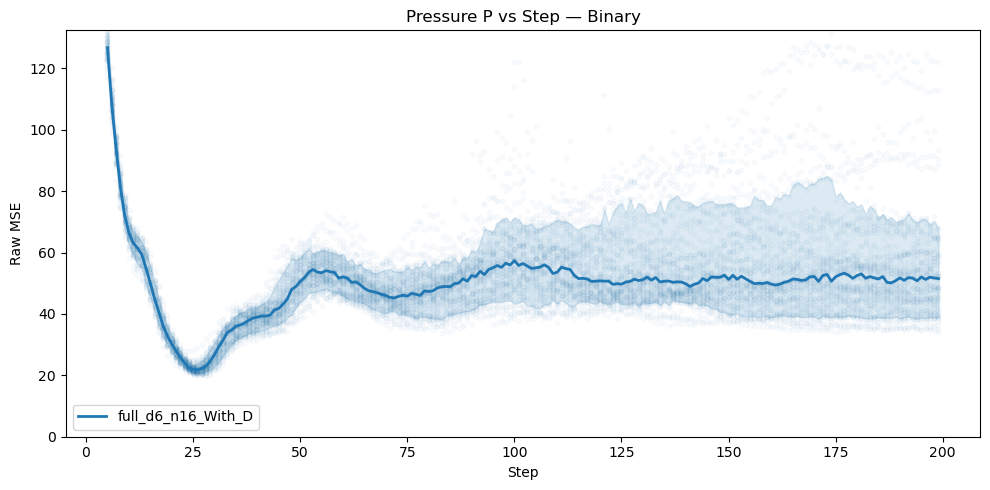

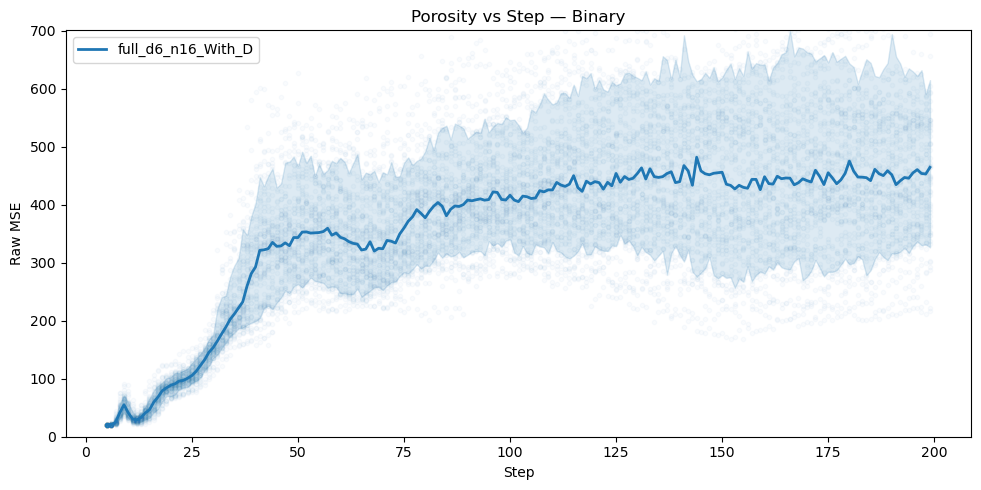

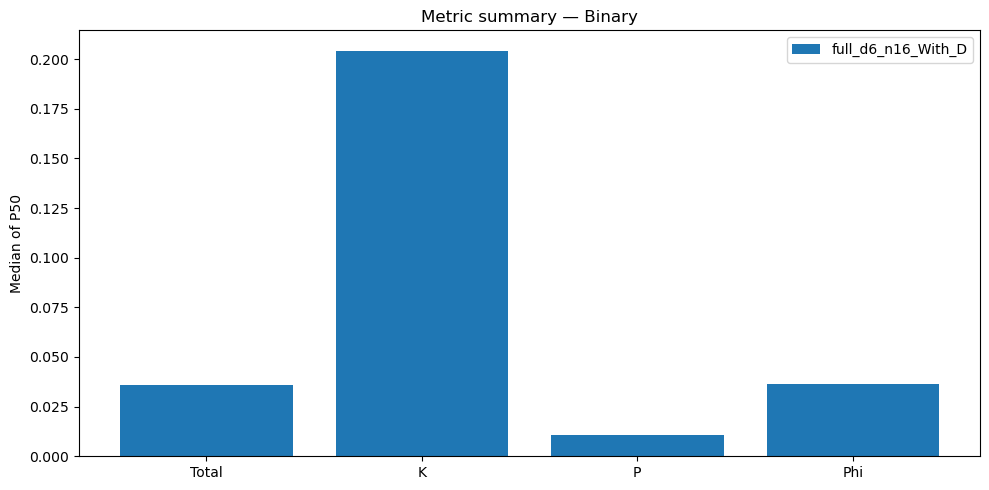

In [41]:
models_to_plot = [
    ["full_d6_n16_With_D"]
]
# One plot per metric (normalized + darcy)
for model_names in models_to_plot:
    for mk in METRICS.keys():
        plot_metric_timeseries(
            model_names,
            mk,
            kind=0,
            start_step=5,
            show_points=True,
            point_stride=1,
            transparency=0.025,
            log_y=True,
        )

    # Combined summary (nmse)
    plot_combined_summary_bar(model_names, kind=0)